# Handwritten Digit Recognition

## Libraries used

In [3]:
# %pip install tensorflow
# %pip install keras
# %pip install scikit-image
# %pip install numpy

# uncomment the above lines to the top of your code to install the necessary packages, and add any other packages you may need in the same format.
import numpy as np
import tensorflow 
import keras  
import os
import glob
import skimage
from skimage import io
import random 
import matplotlib.pyplot as plt  
import pandas as pd
%matplotlib inline

2025-03-26 20:17:10.705414: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Importing Unprocessed data, cleaning and preprocessing

### Importing data

In [4]:
dataset = pd.read_csv("data/optical+recognition+of+handwritten+digits/optdigits-orig.cv", 
                 delim_whitespace=True, header=None, skiprows=21) # path to unprocessed dataset

### Plotting Image from data

In [ ]:
string = dataset.iloc[0, 0] # get the first row of the first digit 
print(string) # print row of the first digit
print(len(string)) # this should give us the number of pixels in each row of a digit, thus the shape of the image

00000000000001100111100000000000
32


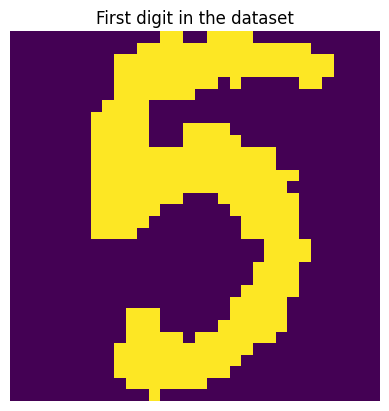

In [20]:
lines = [list(map(int, list(dataset.iloc[i, 0]))) for i in range(32)] # get the first 32 rows of the first digit and convert them to a list of lists
image = np.array(lines) # convert the list of lists to a numpy array


plt.imshow(image) # plot 
plt.title("First digit in the dataset") 
plt.axis('off')
plt.show()

> Since our data is just binary and not images, we will need to preprocess the data in a way that simulates real world image data. That way it will make the models train on data that can be applied to images. 

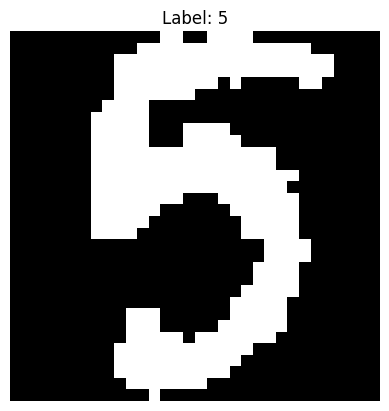

In [ ]:
digits = [] # list to store the digits
labels = [] # list to store the labels of the digits
num_of_digits = len(dataset) # number of digits in the dataset
inc_label = num_of_digits // 33 # number of digits per label, the 33rd line after each digit is the label

for i in range(inc_label): # loop through the dataset with digits and labels
    digit_start = i * 33 # start of the digit
    digit_end = digit_start + 32 # end of the digit
    label = digit_end # label of the digit

    image = np.array([
        list(map(int, list(dataset.iloc[j, 0])))
        for j in range(digit_start, digit_end)
    ]) # convert the digit to a 32x32 image

    digits.append(image) # add the image to the list of digits
    labels.append(int(dataset.iloc[label, 0])) # add the label to the list of labels as a number


plt.imshow(digits[0], cmap='gray') # grayscale image for computer vision 
plt.title(f"Label: {labels[0]}") # get first digit's label
plt.axis('off')
plt.show()


### Prepare data for SVM

### Prepare data for CNN